# AG-HYPOPT · Trial 01

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

This is the **first trial** of the campaign: `trials.json` has an empty `trials` list, so there are no previous trials and no recorded objective yet. Nothing is known from this campaign's own history.

The campaign tunes four learning-rate schedule knobs of the series-21 mechanism on real data, with **no gradient clipping and no parameter clamps** (`CLIP=inf`): `lr_mu`, `mu_anneal`, `lr_gamma`, `gamma_anneal` (see `space.json`). Pre-registered default config (`DEFAULT_CONFIG`): `lr_mu=0.05`, `mu_anneal=0.5`, `lr_gamma=0.5`, `gamma_anneal=0.5`. The objective is the T-weighted mean of capped per-cell relative-squared errors over the 8-experiment benchmark (1nW/3nW x Trans05/20/60/100), weighted toward high transmission (`w=0.25+0.75*T/100`).

Because the registry is empty, the only existing reference point for the first pick is the human-chosen default configuration, and the objective from cell 2 reports no expected-improvement value (`ei = -`, `phase = uniform`: the first 5 trials are an uninformed uniform exploration).

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_01'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = uniform  (0/5 trials)
ID |     ei | params
 1 |      - | {"gamma_anneal": 0.46063946223023106, "lr_gamma": 0.9529405115096385, "lr_mu": 0.07635900829621871, "mu_anneal": 0.9486494471372439}
 2 |      - | {"gamma_anneal": 0.2806483068094369, "lr_gamma": 0.4521601265239468, "lr_mu": 0.41471278394111866, "mu_anneal": 0.4091991363691613}
 3 |      - | {"gamma_anneal": 0.49463431890575354, "lr_gamma": 0.07618115758091495, "lr_mu": 0.37798898879402926, "mu_anneal": 0.5381433132192782}
 4 |      - | {"gamma_anneal": 0.29675854484918296, "lr_gamma": 0.7990072682569841, "lr_mu": 0.15508144049936426, "mu_anneal": 0.4534978894806515}
 5 |      - | {"gamma_anneal": 0.12063752752244827, "lr_gamma": 0.43295733712477275, "lr_mu": 0.10571034413469406, "mu_anneal": 0.2623133404418495}
 6 |      - | {"gamma_anneal": 0.6753282053670473, "lr_gamma": 0.3163883200867379, "lr_mu": 0.24516953234365935, "mu_anneal": 0.9807371998012386}
 7 |      - | {"gamma_anneal": 0.8654914742974081, "lr_gamma": 0.73

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

The registry is empty (no previous trials), so there is nothing in the history to exploit and nothing to compare against: cell 2 confirms the campaign is in its `uniform` phase (0/5 trials), drawing all 10 candidates from the raw search space with no expected-improvement estimate. There is therefore no informed candidate to prefer. The sensible first pick is the candidate that is most *central* in the normalized hyperparameter cube and closest to the pre-registered default config (`lr_mu=0.05`, `mu_anneal=0.5`, `lr_gamma=0.5`, `gamma_anneal=0.5`), i.e. the least corner-like configuration — it is the most informative and least fragile baseline from which the next trials can learn a direction.

Mapping the candidates to normalized (unit-cube) coordinates with the ranges from `space.json`:
- candidate 2: `lr_mu` 0.83, `mu_anneal` 0.41, `lr_gamma` 0.42, `gamma_anneal` 0.31 (squared distance to center 0.157)
- candidate 4: `lr_mu` 0.30, `mu_anneal` 0.45, `lr_gamma` 0.79, `gamma_anneal` 0.33 (squared distance to center 0.153)
- candidate 5: `lr_mu` 0.20, `mu_anneal` 0.26, `lr_gamma` 0.40, `gamma_anneal` 0.13 (0.288)
- candidate 3/6/7/9: farther out (>0.28).

Candidates 2 and 4 are the two most central and are practically tied on centrality, but candidate 4 is much closer to the human default in the `lr_mu` coordinate (0.155 vs 0.415 against a default of 0.05; the raw measured `|grad_mu|` spans 2.0-176.6, so `lr_mu` is the most scale-sensitive knob and the one most worth anchoring near its known-good value first). Its `mu_anneal` (0.453), `lr_gamma` (0.799) and `gamma_anneal` (0.297) all sit at moderate, non-extreme values, giving a balanced first data point that exercises every schedule dimension without pushing any one to a corner.

I choose candidate 4 (4 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 4            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.29675854484918296, 'lr_gamma': 0.7990072682569841, 'lr_mu': 0.15508144049936426, 'mu_anneal': 0.4534978894806515}
Running  1nW Trans05 ... 

μ 9.39 -> 10.22 | γ 8.5 -> 4.71 | NLL 1.27


Running  1nW Trans20 ... 

μ 17.32 -> 44.53 | γ 8.5 -> 6.24 | NLL 5.39


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 79.50 | γ 14.1 -> 14.70 | NLL 3.32


Running 3nW Trans100 ... 

μ 175.71 -> 108.75 | γ 14.1 -> 14.08 | NLL 3.17



Total: 7.3 min


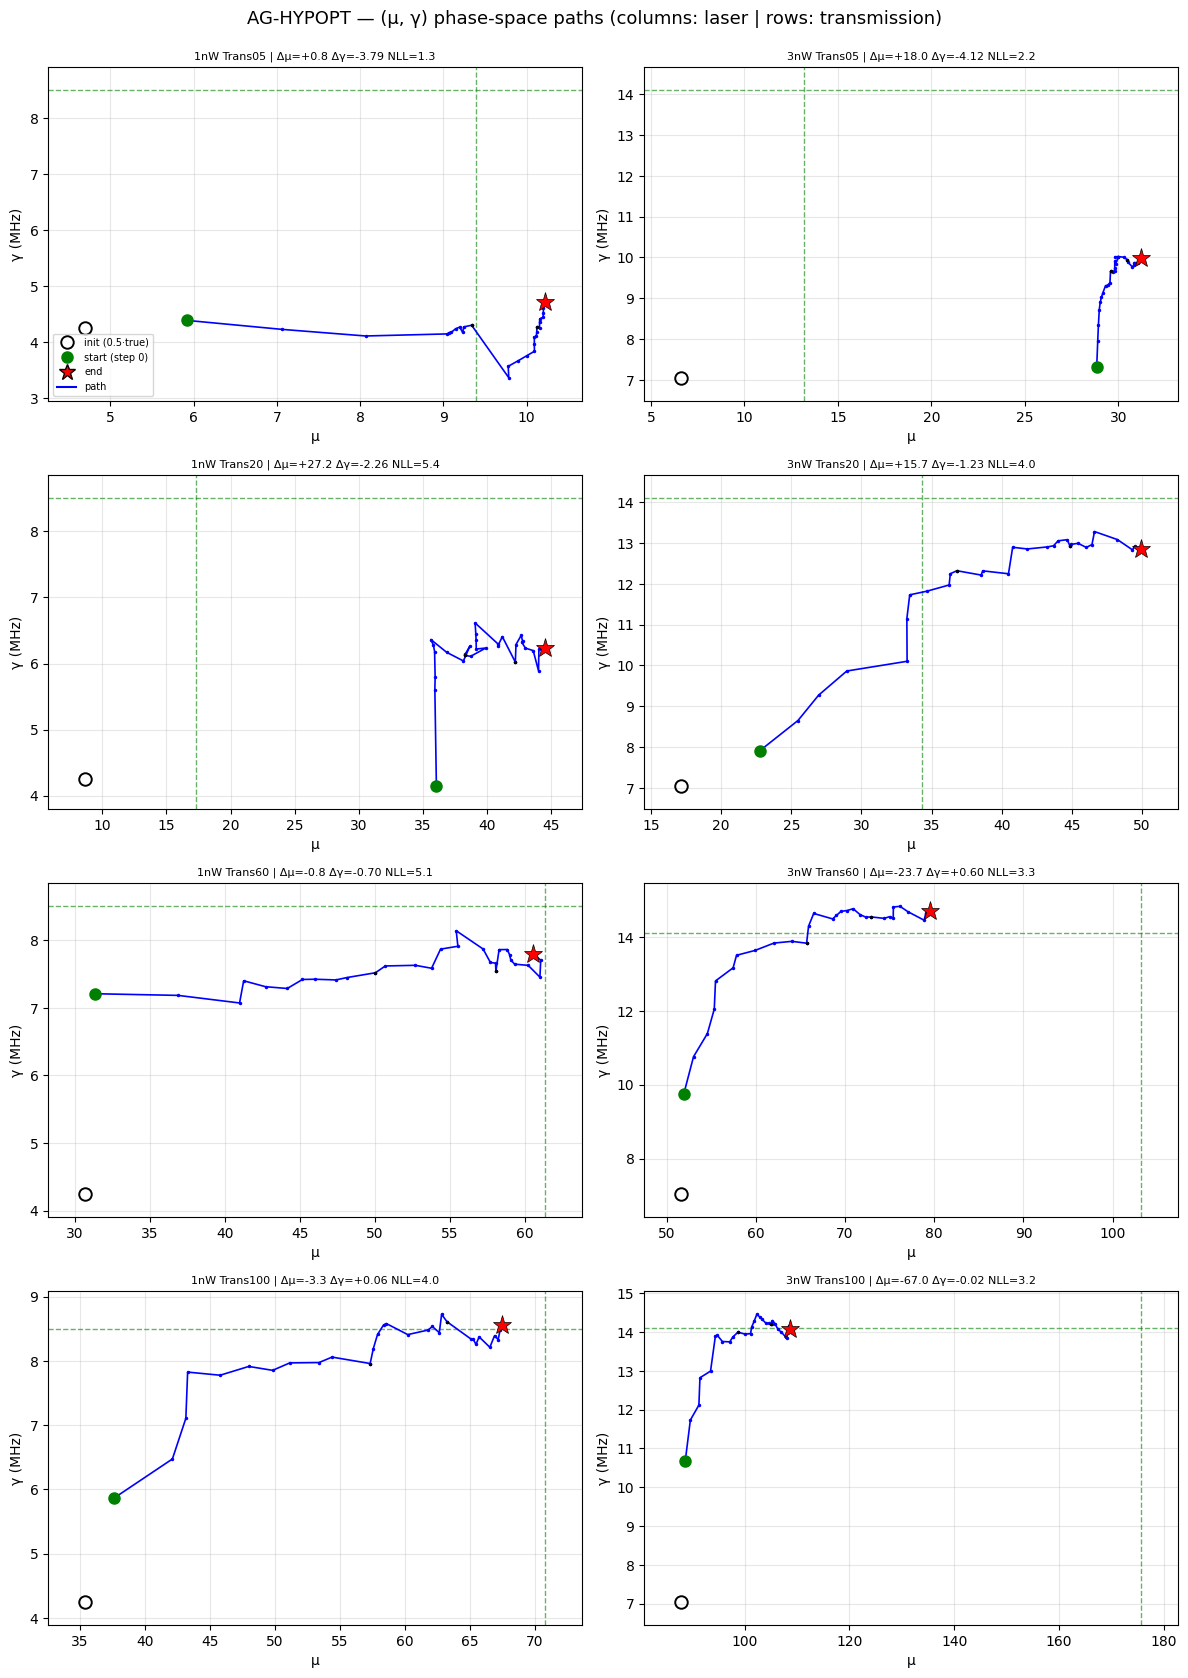

trial finished in 7.4 min
objective = 0.1127 ± 0.0825
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39   10.22    +8.8 |     8.50    4.71   -44.6
1nW Trans20       17.32   44.53  +157.2 |     8.50    6.24   -26.6
1nW Trans60       61.37   60.58    -1.3 |     8.50    7.80    -8.3
1nW Trans100       70.82   67.49    -4.7 |     8.50    8.56    +0.7
3nW Trans05       13.20   31.23  +136.5 |    14.10    9.98   -29.2
3nW Trans20       34.28   49.94   +45.7 |    14.10   12.87    -8.7
3nW Trans60      103.20   79.50   -23.0 |    14.10   14.70    +4.2
3nW Trans100      175.71  108.75   -38.1 |    14.10   14.08    -0.2

weighted objective (T-graded, cap=1.0) = 0.1127 | diverged cells: 0
μ: RMSE 28.213 (rel 77.1%, bias -4.132) | γ: RMSE 2.202 (rel 21.5%, bias -1.434)


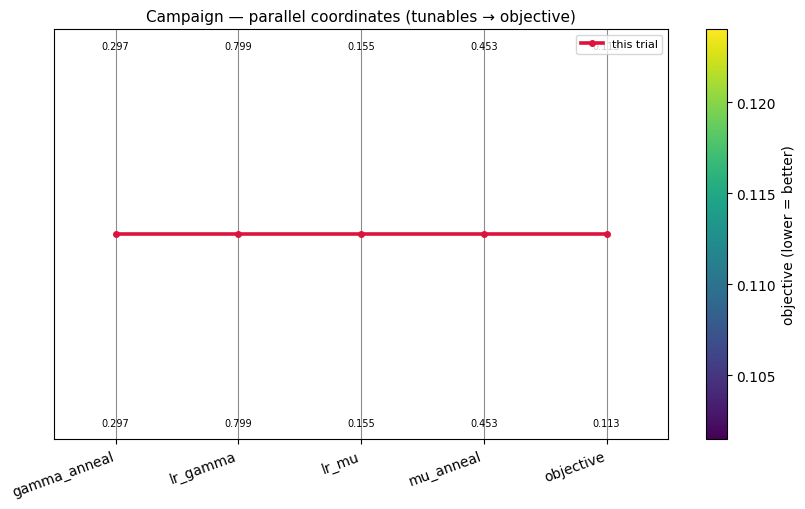

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 01 ran chosen candidate 4: `lr_mu=0.1551`, `mu_anneal=0.4535`, `lr_gamma=0.7990`, `gamma_anneal=0.2968` — the first recorded entry of the campaign (the registry was empty before it, so there is no previous trial to compare against). The run completed in 7.4 min (100x30 on the 8-experiment benchmark) with **no diverged cells** and objective **0.1127 +/- 0.0825** (T-weighted mean of capped rel-sq errors; the +/- is the SE across the 16 channel cells).

Aggregate accuracy: **mu rel-RMSE 77.1%** (RMSE 28.21, bias -4.13); **gamma rel-RMSE 21.5%** (RMSE 2.20, bias -1.43). The objective's residual is dominated by mu; gamma is comparatively well recovered overall.

Per-cell relative errors (Delta = (fit-true)/true):
- **mu:** 1nW T05 +8.8%, T20 **+157.2%**, T60 -1.3%, T100 -4.7% | 3nW T05 **+136.5%**, T20 +45.7%, T60 -23.0%, T100 -38.1%.
- **gamma:** 1nW T05 **-44.6%**, T20 -26.6%, T60 -8.3%, T100 +0.7% | 3nW T05 -29.2%, T20 -8.7%, T60 +4.2%, T100 -0.2%.

Two clean patterns:
1. **mu overshoots at low/mid transmission and undershoots at high transmission.** The two large blow-ups are 1nW T20 (+157%, capped to 1.0) and 3nW T05 (+137%), both at low-to-mid signal; at high T mu now undershoots (3nW T100 -38%, 3nW T60 -23%) while 1nW T60/T100 land near-perfect (-1.3%, -4.7%). Because the objective weights high T most (w=1.0 at T100, 0.70 at T60, 0.29 at T05), the high-T mu undershoot carries the largest weight in the 0.1127.
2. **gamma tracks well at high T and degrades only at low T.** At T100 gamma is within 0.7% (1nW) / 0.2% (3nW); at T60 within ~4-8%. The degradation is confined to T05 (-44.6% / -29.2%) and T20 (-26.6% / -8.7%) — the signature of the known low-count gamma noise/freeze regime. Notably there is **no gamma divergence**: unlike the 21i real-data run (1 divergence at 1nW T05), this schedule kept gamma inside the guard band on all 8 cells.

**Summary:** Trial 01 (lr_mu=0.1551, mu_anneal=0.4535, lr_gamma=0.7990, gamma_anneal=0.2968): objective 0.1127 +/- 0.0825, 0 diverged cells; gamma within ~1% at T100 but under-recovered at low T (-45/-29% at T05), while mu overshoots at mid transmission (+137-157%) and undershoots at high T (-23 to -38%).
**Key insight:** The residual is a mu-location problem (large low/mid-T overshoot plus high-T undershoot, the latter weighted most), not a gamma-divergence one: gamma is accurate at high T and degrades only in the known low-count regime, with no diverged cell.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** Both error patterns are *per-regime*: the mu overshoot lives at 1nW/3nW T20 while the mu undershoot lives at 3nW T60/T100, and the gamma under-recovery is confined to T05/T20. A single global (lr_mu, mu_anneal, lr_gamma, gamma_anneal) cannot express regime-dependent behaviour. If later trials show the schedule knobs cannot fix the mid-T overshoot and the high-T undershoot at the same time, the natural structural candidate is a per-experiment (per-transmission) LR schedule, or a mu step size adapted to n_target — but that is outside this campaign's hyperparameter scope, so it is recorded here only.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 01 (lr_mu=0.1551, mu_anneal=0.4535, lr_gamma=0.7990, gamma_anneal=0.2968): objective 0.1127 +/- 0.0825, 0 diverged cells; gamma within ~1% at T100 but under-recovered at low T (-45/-29% at T05), while mu overshoots at mid transmission (+137-157%) and undershoots at high T (-23 to -38%)"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "The residual is a mu-location problem (large low/mid-T overshoot plus high-T undershoot, the latter weighted most), not a gamma-divergence one: gamma is accurate at high T and degrades only in the known low-count regime, with no diverged cell"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_01 | current best: trial_01


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_02.ipynb. Open it and follow its cells from the top.
